# Monotonic Polynomial Approximation with Gurobi and Python
version 1.1.2

This is just going to be a simple test run first. Not sure how well it will work.

In [1]:
# Let's start off by loading in the packages

# Let's load in the necessary packages
import pandas as pd
import datetime
import os
import timeit
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB
import numpy as np

Using the previous version of this file I created a csv file that already has sample data that we can use. It will be increasing and thus we can try to fit a curve and also force it to be monotonic by adding a constraint for the derivative.

In [2]:
# Loading in the data
file_name = os.fsdecode("sample_approximation_data.csv")
sample_approximation_data = pd.read_csv(file_name)
# sample_approximation_data

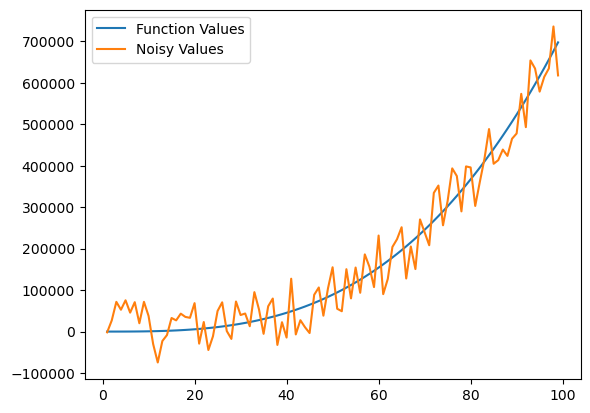

In [3]:
# Let's graph the data first again:

pltx = sample_approximation_data['x_values']
plty = sample_approximation_data['y_real']
plty2 = sample_approximation_data['y_values']

# Plotting the lines
plt.plot(pltx, plty, label = "Function Values")
plt.plot(pltx, plty2, label = "Noisy Values")

plt.legend()
plt.show()

The graph above has both the function values (blue line) and the "noisy" data values (orange line).
\
Function values were created using the original polynomial of degree 3 with the following coefficient array: [-0.79224738, -0.26940259, -0.89737457,  0.17712193].
\
(The noisy values were created by adding a uniform random number from -80,000 to 80,000).

## Curve Approximation with Gurobi
Now I want to try fitting a polynomial and at the same time forcing it to be monotonic.

In [4]:
### CREATING THE MODEL ###
    
model = gp.Model('CurveFitting')

inf = GRB.INFINITY

Set parameter Username
Academic license - for non-commercial use only - expires 2025-09-12


In [5]:
# Let's "extract" the x and y values so that we won't have to type so much.
x_values = sample_approximation_data['x_values']
y_values = sample_approximation_data['y_values']

In [6]:
## Now let's create variables for the curve fitting and approximation

# We're creating variables for the coefficients of our polynomial curve
a_coeff = model.addVar(lb=-inf,ub=inf,name="")
b_coeff = model.addVar(lb=-inf,ub=inf,name="")
c_coeff = model.addVar(lb=-inf,ub=inf,name="")

# We need to add an error variable which takes in the error term
error = [model.addVar(lb=-inf,ub=inf,name="") for i in range(len(x_values))]

# And a variable for the intercept.
d_intercept = model.addVar(lb=-inf,ub=inf,name="")


In [7]:
# Now we need to add a constraint that will govern our curve fitting

for i in range(len(x_values)):

    # Constraint that just states the equation of the error term, which we aim to minimize.
    model.addConstr(error[i] == y_values[i] - a_coeff*x_values[i]**3 - b_coeff*x_values[i]**2 - c_coeff*x_values[i] - d_intercept)

    # What I'm adding here is a constraint for the derivative of our polynomial.
    # We want the derivative of the polynomial to be nonnegative over all x.
    model.addConstr(3*a_coeff*x_values[i]**2 + 2*b_coeff*x_values[i] + c_coeff >= 0)

In [8]:
### Now let's set up the objective function

obj = 0

obj += sum([(error[i])**2 for i in range(len(x_values))])

In [9]:
### Now setting the objective into gurobi and asking it to solve:

model.setObjective(obj)
model.optimize()

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: AMD Ryzen 5 8645HS w/ Radeon 760M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 198 rows, 103 columns and 792 nonzeros
Model fingerprint: 0x81fb4646
Model has 99 quadratic objective terms
Coefficient statistics:
  Matrix range     [1e+00, 1e+06]
  Objective range  [0e+00, 0e+00]
  QObjective range [2e+00, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+03, 7e+05]
Presolve time: 0.00s
Presolved: 198 rows, 103 columns, 792 nonzeros
Presolved model has 99 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 Free vars  : 103
 AA' NZ     : 1.950e+04
 Factor NZ  : 1.970e+04
 Factor Ops : 2.607e+06 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl   

In [10]:
# Now let's create the function with our estimated coefficients from gurobi:

# First getting the estimates from the gurobi model:
a_est = a_coeff.X
b_est = b_coeff.X
c_est = c_coeff.X
d_int_est = d_intercept.X

error_est = []
for i in range(len(x_values)):
    error_est.append(error[i].X)


In [11]:
# Let's try and put all of this into a curve:

y_estimates = []

for i in range(len(x_values)):
    y_estimates.append(a_est*x_values[i]**3+b_est*x_values[i]**2+c_est*x_values[i]+d_int_est)

# y_estimates

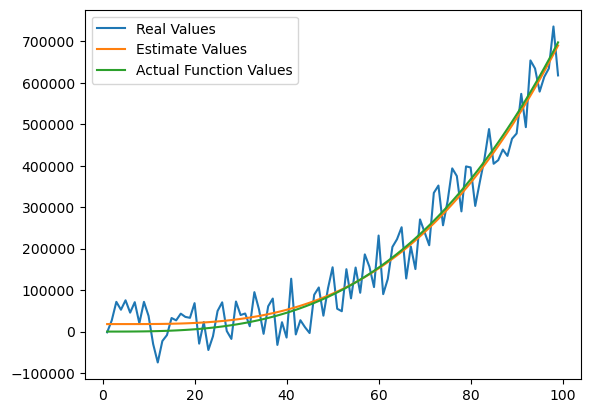

In [17]:
# Now let's plot the same graph above and check the "noise"

pltx = x_values
plty = y_values
plty2 = y_estimates

# Plotting the lines
plt.plot(pltx, plty, label = "Real Values")
plt.plot(pltx, plty2, label = "Estimate Values")
plt.plot(pltx, sample_approximation_data['y_real'], label = "Actual Function Values")

plt.legend()
plt.show()

In [13]:
# Our Estimated coefficients
[a_est,b_est,c_est,d_int_est]

[0.8122921252372083, -12.51086314282178, 64.18672203542717, 17996.13021330778]

In [14]:
# Let's try and graph the derivative of our estimated polynomial to check if it's never negative:

derivative_values = []

for i in range(len(x_values)):
    derivative_values.append(3*a_est*x_values[i]**2 + 2*b_est*x_values[i] + c_est)

# derivative_values


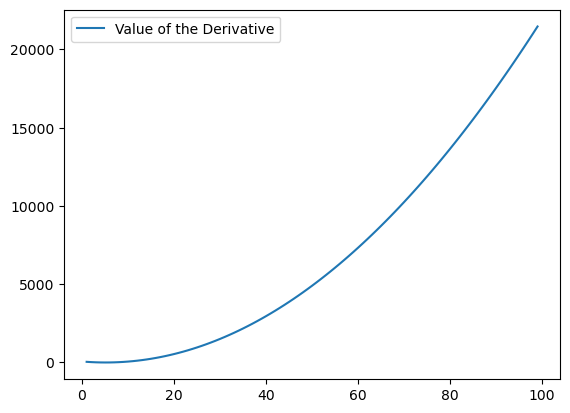

In [15]:
# Now let's plot the derivative

pltx = x_values
plty = derivative_values

# Plotting the lines
plt.plot(pltx, plty, label = "Value of the Derivative")

plt.legend()
plt.show()

In [16]:
# There seem to be a few values below zero, but let's take a look at how many, and how much they go below zero:

negative_derivatives = [n for n in derivative_values if n < 0]
negative_derivatives

[-1.4210854715202004e-14]